In [2]:
import pandas as pd

# بارگذاری دیتاست
df = pd.read_csv('heart_2020_cleaned.csv')

# چند تا اطلاعات کلی
print("تعداد ردیف‌ها و ستون‌ها:", df.shape)
print()
print("اسم ستون‌ها:")
print(df.columns.tolist())
print()
print("۵ ردیف اول:")
df.head()

تعداد ردیف‌ها و ستون‌ها: (319795, 18)

اسم ستون‌ها:
['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']

۵ ردیف اول:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
# بررسی مقادیر گمشده و آمار کلی
print("آیا مقدار گمشده داریم؟")
print(df.isnull().sum())
print()
print("چند نفر بیماری قلبی دارن؟")
print(df['HeartDisease'].value_counts())
print()
print("درصد بیماران:")
print(df['HeartDisease'].value_counts(normalize=True) * 100)

آیا مقدار گمشده داریم؟
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

چند نفر بیماری قلبی دارن؟
HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64

درصد بیماران:
HeartDisease
No     91.440454
Yes     8.559546
Name: proportion, dtype: float64


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# تبدیل همه ستون‌های متنی به عدد
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

print("بعد از تبدیل:")
print(df_encoded.head())

بعد از تبدیل:
   HeartDisease    BMI  Smoking  AlcoholDrinking  Stroke  PhysicalHealth  \
0             0  16.60        1                0       0             3.0   
1             0  20.34        0                0       1             0.0   
2             0  26.58        1                0       0            20.0   
3             0  24.21        0                0       0             0.0   
4             0  23.71        0                0       0            28.0   

   MentalHealth  DiffWalking  Sex  AgeCategory  Race  Diabetic  \
0          30.0            0    0            7     5         2   
1           0.0            0    0           12     5         0   
2          30.0            0    1            9     5         2   
3           0.0            0    0           11     5         0   
4           0.0            1    0            4     5         0   

   PhysicalActivity  GenHealth  SleepTime  Asthma  KidneyDisease  SkinCancer  
0                 1          4        5.0       1    

In [5]:
# X = ویژگی‌ها (چیزی که به مدل میدیم)
# y = هدف (چیزی که می‌خوایم پیش‌بینی کنه)

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("شکل X:", X.shape)
print("شکل y:", y.shape)
print()
print("چند نمونه از y:")
print(y.value_counts())

شکل X: (319795, 17)
شکل y: (319795,)

چند نمونه از y:
HeartDisease
0    292422
1     27373
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("تعداد داده آموزش:", X_train.shape)
print("تعداد داده تست:", X_test.shape)

تعداد داده آموزش: (255836, 17)
تعداد داده تست: (63959, 17)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("نمونه‌ای از داده نرمال شده:")
print(X_train_scaled[:2])

نمونه‌ای از داده نرمال شده:
[[-0.78598116  1.1935544  -0.27050619 -0.19722674 -0.42351474 -0.48991929
  -0.40126323  1.05217306  1.2592872   0.49758547 -0.41974443  0.53776441
   1.15913555 -0.06598811 -0.39368073 -0.19563841 -0.32056262]
 [-0.13694972  1.1935544  -0.27050619  5.07030641  3.3547987  -0.48991929
  -0.40126323  1.05217306  0.13690441  0.49758547 -0.41974443  0.53776441
  -0.14387077 -0.76336636 -0.39368073 -0.19563841 -0.32056262]]


In [8]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(17,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

print("آموزش تموم شد!")

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9157 - loss: 0.2294 - val_accuracy: 0.9144 - val_loss: 0.2299
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9158 - loss: 0.2286 - val_accuracy: 0.9146 - val_loss: 0.2291
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9159 - loss: 0.2283 - val_accuracy: 0.9155 - val_loss: 0.2282
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9159 - loss: 0.2283 - val_accuracy: 0.9145 - val_loss: 0.2298
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9160 - loss: 0.2280 - val_accuracy: 0.9150 - val_loss: 0.2286
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9159 - loss: 0.2277 - val_accuracy: 0.9145 - val_loss: 0.2295
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9159 - loss: 0.2276 - val_accuracy: 0.9145 - val_loss: 0.2292
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9161 - loss: 0.2276 - val_accuracy: 0.

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print("گزارش کامل:")
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred))

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
گزارش کامل:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     58367
           1       0.71      0.02      0.03      5592

    accuracy                           0.91     63959
   macro avg       0.81      0.51      0.49     63959
weighted avg       0.90      0.91      0.87     63959

AUC Score: 0.5080707711966016


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("قبل از SMOTE:", y_train.value_counts().to_dict())
print("بعد از SMOTE:", dict(zip(*[['سالم','بیمار'],
      [sum(y_train_resampled==0), sum(y_train_resampled==1)]])))

قبل از SMOTE: {0: 234055, 1: 21781}
بعد از SMOTE: {'سالم': 234055, 'بیمار': 234055}


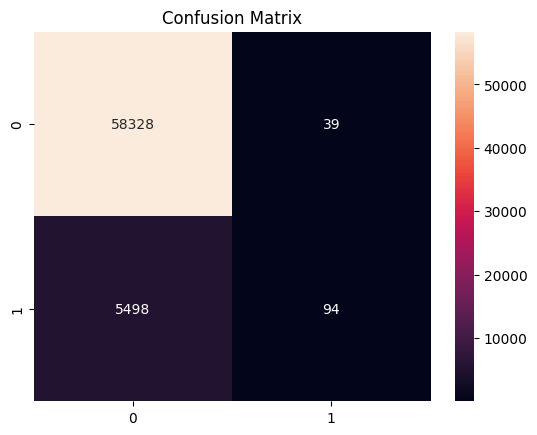

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [14]:
model2 = keras.Sequential([
    keras.layers.Input(shape=(17,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train_resampled, y_train_resampled,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

print("آموزش مدل جدید تموم شد!")

Epoch 1/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7565 - loss: 0.4904 - val_accuracy: 0.7161 - val_loss: 0.6216
Epoch 2/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7679 - loss: 0.4723 - val_accuracy: 0.6830 - val_loss: 0.6496
Epoch 3/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7714 - loss: 0.4689 - val_accuracy: 0.7133 - val_loss: 0.6160
Epoch 4/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7735 - loss: 0.4653 - val_accuracy: 0.6660 - val_loss: 0.6781
Epoch 5/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7739 - loss: 0.4644 - val_accuracy: 0.6903 - val_loss: 0.6496
Epoch 6/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7754 - loss: 0.4629 - val_accuracy: 0.6802 - val_loss: 0.6497
Epoch 7/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7758 - loss: 0.4625 - val_accuracy: 0.6845 - val_loss: 0.6483
Epoch 8/10
1463/1463 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7757 - loss: 0.4617 -

1999/1999 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
گزارش مدل جدید:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     58367
           1       0.26      0.64      0.37      5592

    accuracy                           0.81     63959
   macro avg       0.61      0.74      0.63     63959
weighted avg       0.90      0.81      0.84     63959

AUC Score: 0.7351656001944972


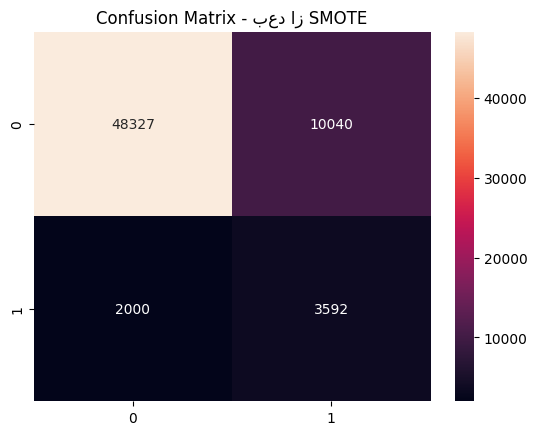

In [15]:
y_pred2 = (model2.predict(X_test_scaled) > 0.5).astype(int)

print("گزارش مدل جدید:")
print(classification_report(y_test, y_pred2))
print("AUC Score:", roc_auc_score(y_test, y_pred2))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d')
plt.title("Confusion Matrix - بعد از SMOTE")
plt.show()